# Driver Notebook

### Matthew Eckert

### EECE 5639: Project 1

This python note will execute the code from the MotionDetector module to complete the required tasks and variations for the assignment. Additionally, all outputs will be within the notebook itself.

In [1]:
#Imports
from MotionDetector import *
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import scipy

### General Case

[i] Loading frames from directory:  ../RedChair


Frames to Grayscale: 100%|██████████| 353/353 [00:00<00:00, 1111.62it/s]


[i] Loading frames from directory:  ../Office


Frames to Grayscale: 100%|██████████| 1070/1070 [00:00<00:00, 1325.41it/s]


[i] Loading frames from directory:  ../EnterExitCrossingPaths2cor


Frames to Grayscale: 100%|██████████| 485/485 [00:00<00:00, 869.02it/s]


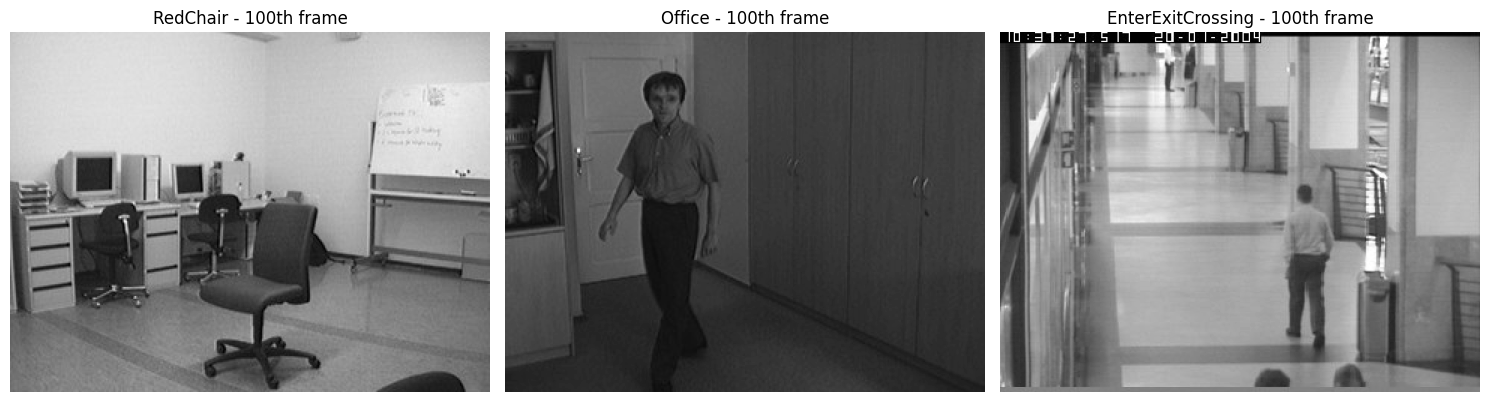

In [2]:
# Read in a sequence of image frames and make them grayscale

redChar_path = "../RedChair"
Office_path = "../Office"
EnterExitCrossing = "../EnterExitCrossingPaths2cor"

redChar_gray = load_frames_and_grayscale(redChar_path) 
Office_gray = load_frames_and_grayscale(Office_path)
EnterExitCrossing_gray = load_frames_and_grayscale(EnterExitCrossing)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# Plot RedChair
axes[0].imshow(redChar_gray[100], cmap='gray')
axes[0].set_title('RedChair - 100th frame')
axes[0].axis('off')
# Plot Office
axes[1].imshow(Office_gray[100], cmap='gray')
axes[1].set_title('Office - 100th frame')
axes[1].axis('off')
# Plot EnterExitCrossing
axes[2].imshow(EnterExitCrossing_gray[100], cmap='gray')
axes[2].set_title('EnterExitCrossing - 100th frame')
axes[2].axis('off')
plt.tight_layout()
plt.show()

[i] Applying simple difference operator to frames
[i] Applying simple difference operator to frames
[i] Applying simple difference operator to frames
[i] Applying Gaussian difference operator to frames
[i] Applying Gaussian difference operator to frames
[i] Applying Gaussian difference operator to frames
[i] Applying Gaussian difference operator to frames
[i] Applying Gaussian difference operator to frames
[i] Applying Gaussian difference operator to frames
[i] Applying Gaussian difference operator to frames
[i] Applying Gaussian difference operator to frames
[i] Applying Gaussian difference operator to frames


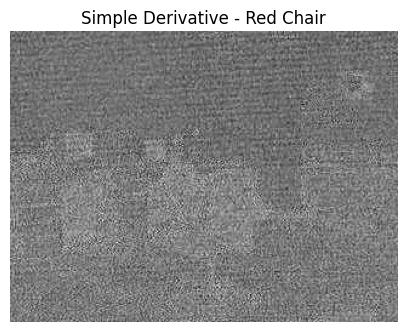

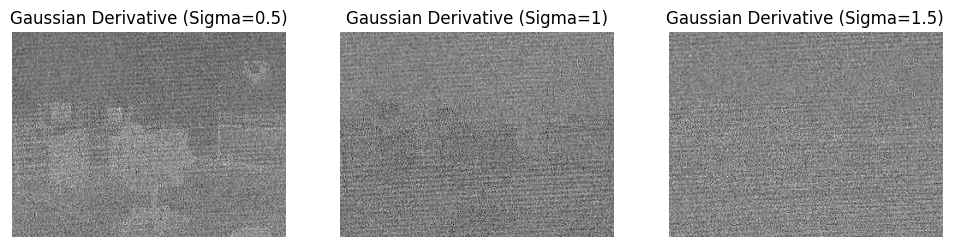


The primary difference between the Simple Finite Difference operator (e.g., [-0.5, 0, 0.5]) and the Gaussian Differential
operator lies in their handling of noise vs. localization.
The simple operator provides a mathematically direct and computationally inexpensive estimate of the temporal derivative,
but it is highly sensitive to high-frequency noise; even minor sensor fluctuations or lighting flickers can be
misinterpreted as motion ("speckling").
In contrast, the Gaussian operator incorporates a smoothing step (controlled by the standard deviation, sigma) before
differentiation. This effectively suppresses high-frequency noise, resulting in cleaner, more coherent motion "blobs",
at the slight cost of temporal precision—potentially causing 'ghosting' or lag if the smoothing is too aggressive for
the object's speed.



In [3]:
# Apply a 1-D differential operator at each pixel to compute a temporal derivative

# Simple diff operator

redChar_simple = apply_simple_diff_operator(redChar_gray)
Office_simple = apply_simple_diff_operator(Office_gray)
EnterExitCrossing_simple = apply_simple_diff_operator(EnterExitCrossing_gray)

# Guassian diff operator
std_devs = [0.5,1,1.5]

redChar_gaussian = []
Office_gaussian = []
EnterExitCrossing_gaussian = []

for std_dev in std_devs:
    redChar_gaussian.append(apply_gaussian_diff_operator(redChar_gray, std_dev))
    Office_gaussian.append(apply_gaussian_diff_operator(Office_gray, std_dev))
    EnterExitCrossing_gaussian.append(apply_gaussian_diff_operator(EnterExitCrossing_gray, std_dev))


# Visualze the differences

# Plot Simple Derivative - Red chair
plt.figure(figsize=(5, 5))
plt.imshow(redChar_simple[100], cmap='gray')
plt.title("Simple Derivative - Red Chair")
plt.axis('off')
plt.show()
# Plot Gaussian Derivatives
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].imshow(redChar_gaussian[0][100], cmap='gray')
axes[0].set_title(f"Gaussian Derivative (Sigma={std_devs[0]})")
axes[0].axis('off')

axes[1].imshow((redChar_gaussian[1][100]), cmap='gray')
axes[1].set_title(f"Gaussian Derivative (Sigma={std_devs[1]})")
axes[1].axis('off')

axes[2].imshow((redChar_gaussian[2][100]), cmap='gray')
axes[2].set_title(f"Gaussian Derivative (Sigma={std_devs[2]})")
axes[2].axis('off')
plt.show()


print("""
The primary difference between the Simple Finite Difference operator (e.g., [-0.5, 0, 0.5]) and the Gaussian Differential
operator lies in their handling of noise vs. localization.
The simple operator provides a mathematically direct and computationally inexpensive estimate of the temporal derivative,
but it is highly sensitive to high-frequency noise; even minor sensor fluctuations or lighting flickers can be
misinterpreted as motion ("speckling").
In contrast, the Gaussian operator incorporates a smoothing step (controlled by the standard deviation, sigma) before
differentiation. This effectively suppresses high-frequency noise, resulting in cleaner, more coherent motion "blobs",
at the slight cost of temporal precision—potentially causing 'ghosting' or lag if the smoothing is too aggressive for
the object's speed.
""")


In [4]:
# Threshold mask with variation

# Determine threshold

# Simple Diff
simple_thresh_red = get_adaptive_threshold(redChar_simple)
simple_thresh_office = get_adaptive_threshold(Office_simple)
simple_thresh_crossing = get_adaptive_threshold(EnterExitCrossing_simple)

# Guassian diff
guassian_thresh_red = []
guassian_thresh_office = []
guassian_thresh_crossing = []

for i in range(3):
    guassian_thresh_red.append(get_adaptive_threshold(redChar_gaussian[i]))
    guassian_thresh_office.append(get_adaptive_threshold(Office_gaussian[i]))
    guassian_thresh_crossing.append(get_adaptive_threshold(EnterExitCrossing_gaussian[i]))


# Form binary masks

# Simple Diff
simple_mask_red = form_binary_mask(redChar_simple, simple_thresh_red)
simple_mask_office = form_binary_mask(Office_simple, simple_thresh_office)
simple_mask_crossing = form_binary_mask(EnterExitCrossing_simple, simple_thresh_crossing)

# Guassian Diff
guassian_mask_red = []
guassian_mask_office = []
guassian_mask_crossing = []

for i in range(3):
    guassian_mask_red.append(form_binary_mask(redChar_gaussian[i], guassian_thresh_red[i]))
    guassian_mask_office.append(form_binary_mask(Office_gaussian[i], guassian_thresh_office[i]))
    guassian_mask_crossing.append(form_binary_mask(EnterExitCrossing_gaussian[i], guassian_thresh_crossing[i]))


[i] Loading frames from directory:  ../RedChair


Frames to color: 100%|██████████| 353/353 [00:00<00:00, 1361.81it/s]


[i] Loading frames from directory:  ../Office


Frames to color: 100%|██████████| 1070/1070 [00:00<00:00, 1511.56it/s]


[i] Loading frames from directory:  ../EnterExitCrossingPaths2cor


Frames to color: 100%|██████████| 485/485 [00:00<00:00, 1069.16it/s]


[i] Recombining mask (351, 240, 320) with trimmed frames (351, 240, 320, 3)
[i] Recombining mask (1068, 240, 320) with trimmed frames (1068, 240, 320, 3)
[i] Recombining mask (483, 288, 384) with trimmed frames (483, 288, 384, 3)
[i] Recombining mask (349, 240, 320) with trimmed frames (349, 240, 320, 3)
[i] Recombining mask (345, 240, 320) with trimmed frames (345, 240, 320, 3)
[i] Recombining mask (341, 240, 320) with trimmed frames (341, 240, 320, 3)
[i] Recombining mask (1066, 240, 320) with trimmed frames (1066, 240, 320, 3)
[i] Recombining mask (1062, 240, 320) with trimmed frames (1062, 240, 320, 3)
[i] Recombining mask (1058, 240, 320) with trimmed frames (1058, 240, 320, 3)
[i] Recombining mask (481, 288, 384) with trimmed frames (481, 288, 384, 3)
[i] Recombining mask (477, 288, 384) with trimmed frames (477, 288, 384, 3)
[i] Recombining mask (473, 288, 384) with trimmed frames (473, 288, 384, 3)


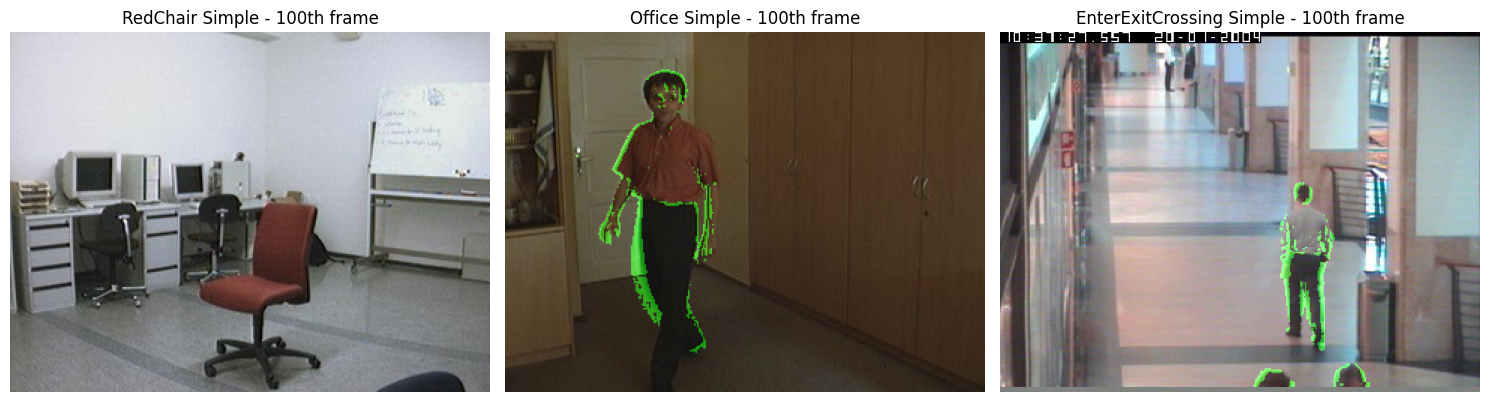

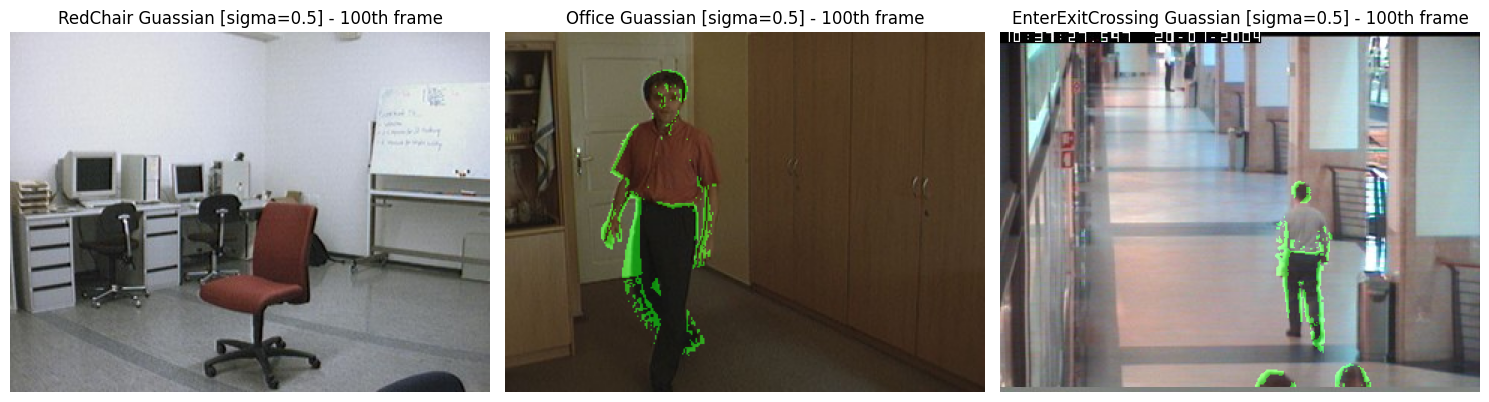

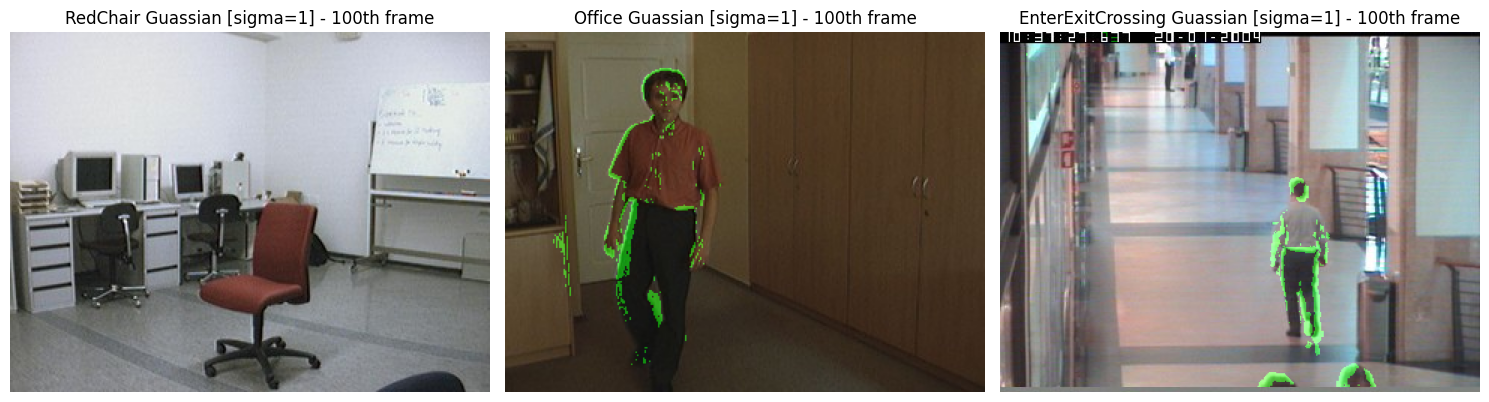

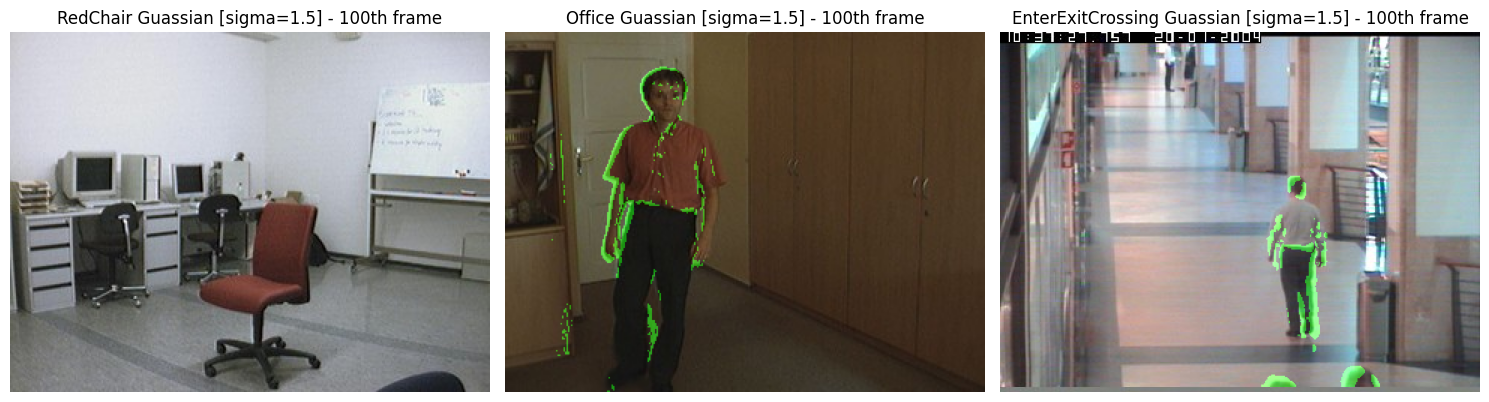

In [10]:
# Form final Results

redChar_color = load_frames_in_color(redChar_path)
office_color = load_frames_in_color(Office_path)
crossing_color =load_frames_in_color(EnterExitCrossing)

# Simple

final_red_simple = recombine_mask_with_color(redChar_color,simple_mask_red)
final_office_simple = recombine_mask_with_color(office_color,simple_mask_office)
final_crossing_simple = recombine_mask_with_color(crossing_color,simple_mask_crossing)

# Guassian
final_red_guassian_1 = recombine_mask_with_color(redChar_color, guassian_mask_red[0])
final_red_guassian_2 = recombine_mask_with_color(redChar_color, guassian_mask_red[1])
final_red_guassian_3 = recombine_mask_with_color(redChar_color, guassian_mask_red[2])

final_office_guassian_1 = recombine_mask_with_color(office_color, guassian_mask_office[0])
final_office_guassian_2 = recombine_mask_with_color(office_color, guassian_mask_office[1])
final_office_guassian_3 = recombine_mask_with_color(office_color, guassian_mask_office[2])

final_crossing_guassian_1 = recombine_mask_with_color(crossing_color, guassian_mask_crossing[0])
final_crossing_guassian_2 = recombine_mask_with_color(crossing_color, guassian_mask_crossing[1])
final_crossing_guassian_3 = recombine_mask_with_color(crossing_color, guassian_mask_crossing[2])

# Display frames
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# Plot RedChair
axes[0].imshow(final_red_simple[100][:,:,::-1])
axes[0].set_title('RedChair Simple - 100th frame')
axes[0].axis('off')
# Plot Office
axes[1].imshow(final_office_simple[100][:,:,::-1])
axes[1].set_title('Office Simple - 100th frame')
axes[1].axis('off')
# Plot EnterExitCrossing
axes[2].imshow(final_crossing_simple[100][:,:,::-1])
axes[2].set_title('EnterExitCrossing Simple - 100th frame')
axes[2].axis('off')
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# Plot RedChair
axes[0].imshow(final_red_guassian_1[100][:,:,::-1])
axes[0].set_title('RedChair Guassian [sigma=0.5] - 100th frame')
axes[0].axis('off')
# Plot Office
axes[1].imshow(final_office_guassian_1[100][:,:,::-1])
axes[1].set_title('Office Guassian [sigma=0.5] - 100th frame')
axes[1].axis('off')
# Plot EnterExitCrossing
axes[2].imshow(final_crossing_guassian_1[100][:,:,::-1])
axes[2].set_title('EnterExitCrossing Guassian [sigma=0.5] - 100th frame')
axes[2].axis('off')
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# Plot RedChair
axes[0].imshow(final_red_guassian_2[100][:,:,::-1])
axes[0].set_title('RedChair Guassian [sigma=1] - 100th frame')
axes[0].axis('off')
# Plot Office
axes[1].imshow(final_office_guassian_2[100][:,:,::-1])
axes[1].set_title('Office Guassian [sigma=1] - 100th frame')
axes[1].axis('off')
# Plot EnterExitCrossing
axes[2].imshow(final_crossing_guassian_2[100][:,:,::-1])
axes[2].set_title('EnterExitCrossing Guassian [sigma=1] - 100th frame')
axes[2].axis('off')
plt.tight_layout()
plt.show()



fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# Plot RedChair
axes[0].imshow(final_red_guassian_3[100][:,:,::-1])
axes[0].set_title('RedChair Guassian [sigma=1.5] - 100th frame')
axes[0].axis('off')
# Plot Office
axes[1].imshow(final_office_guassian_3[100][:,:,::-1])
axes[1].set_title('Office Guassian [sigma=1.5] - 100th frame')
axes[1].axis('off')
# Plot EnterExitCrossing
axes[2].imshow(final_crossing_guassian_3[100][:,:,::-1])
axes[2].set_title('EnterExitCrossing Guassian [sigma=1.5] - 100th frame')
axes[2].axis('off')
plt.tight_layout()
plt.show()

In [11]:
# Reassemble as a final video


# Simple 
output_file = "../output/redchair_simple.mp4"
save_as_video(final_red_simple, output_file, fps=24)

output_file = "../output/office_simple.mp4"
save_as_video(final_office_simple, output_file, fps=24)

output_file = "../output/crossing_simple.mp4"
save_as_video(final_crossing_simple, output_file, fps=24)

# Guassian
output_file = "../output/redchair_gaussian_sigma_05.mp4"
save_as_video(final_red_guassian_1, output_file, fps=24)

output_file = "../output/office_gaussian_sigma_05.mp4"
save_as_video(final_office_guassian_1, output_file, fps=24)

output_file = "../output/crossing_gaussian_sigma_05.mp4"
save_as_video(final_crossing_guassian_1, output_file, fps=24)

output_file = "../output/redchair_gaussian_sigma_1.mp4"
save_as_video(final_red_guassian_2, output_file, fps=24)

output_file = "../output/office_gaussian_sigma_1.mp4"
save_as_video(final_office_guassian_2, output_file, fps=24)

output_file = "../output/crossing_gaussian_sigma_1.mp4"
save_as_video(final_crossing_guassian_2, output_file, fps=24)

output_file = "../output/redchair_gaussian_sigma_15.mp4"
save_as_video(final_red_guassian_3, output_file, fps=24)

output_file = "../output/office_gaussian_sigma_15.mp4"
save_as_video(final_office_guassian_3, output_file, fps=24)

output_file = "../output/crossing_gaussian_sigma_15.mp4"
save_as_video(final_crossing_guassian_3, output_file, fps=24)



[i] Saving video to ../output/redchair_simple.mp4 (351 frames, 320x240, Color=True, Codec=avc1)
[i] Video saved successfully.
[i] Saving video to ../output/office_simple.mp4 (1068 frames, 320x240, Color=True, Codec=avc1)
[i] Video saved successfully.
[i] Saving video to ../output/crossing_simple.mp4 (483 frames, 384x288, Color=True, Codec=avc1)
[i] Video saved successfully.
[i] Saving video to ../output/redchair_gaussian_sigma_05.mp4 (349 frames, 320x240, Color=True, Codec=avc1)
[i] Video saved successfully.
[i] Saving video to ../output/office_gaussian_sigma_05.mp4 (1066 frames, 320x240, Color=True, Codec=avc1)
[i] Video saved successfully.
[i] Saving video to ../output/crossing_gaussian_sigma_05.mp4 (481 frames, 384x288, Color=True, Codec=avc1)
[i] Video saved successfully.
[i] Saving video to ../output/redchair_gaussian_sigma_1.mp4 (345 frames, 320x240, Color=True, Codec=avc1)
[i] Video saved successfully.
[i] Saving video to ../output/office_gaussian_sigma_1.mp4 (1062 frames, 320x2

In [ ]:
# 2D Spatial smoothing variation

# std dev
smoothing_std_dev = 0.5, 1.25, 2.5
 
# 3x3 kernel


# 5x5 kernel


# Redo previous work with both kernels (smiple/guassia -> threshold/mask -> recombine)



In [ ]:
# Generating results for Report

# Show Ghosting between the different stds

